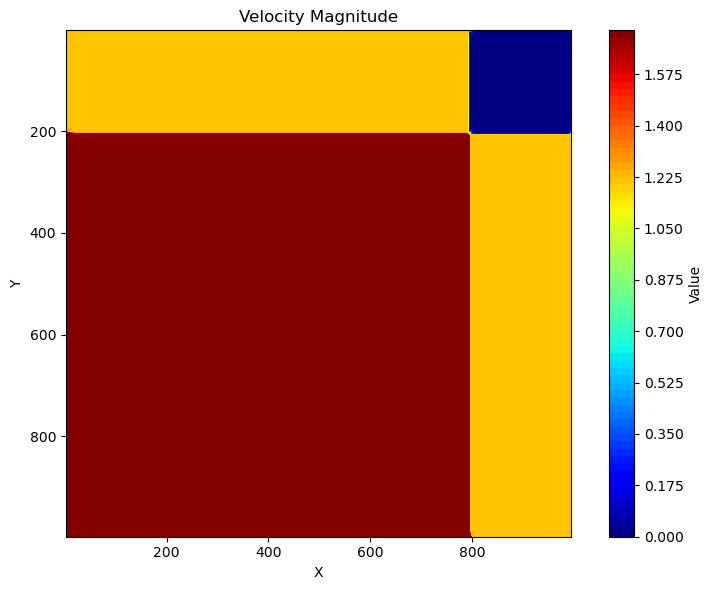

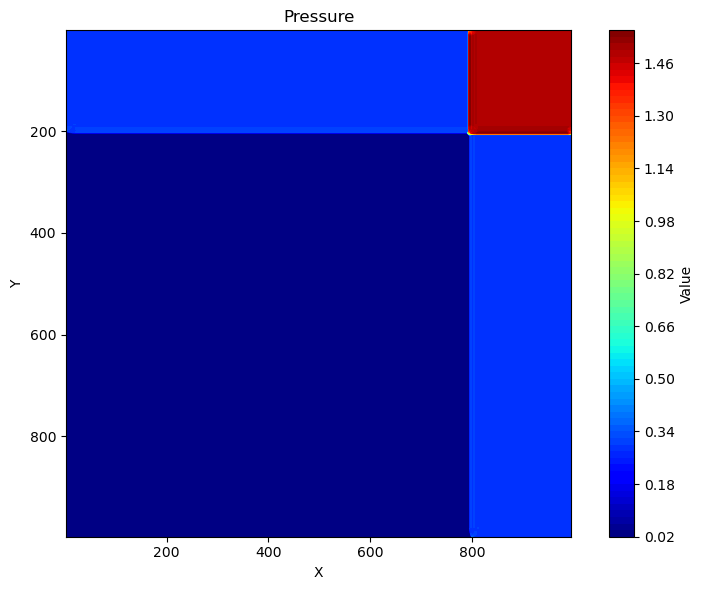

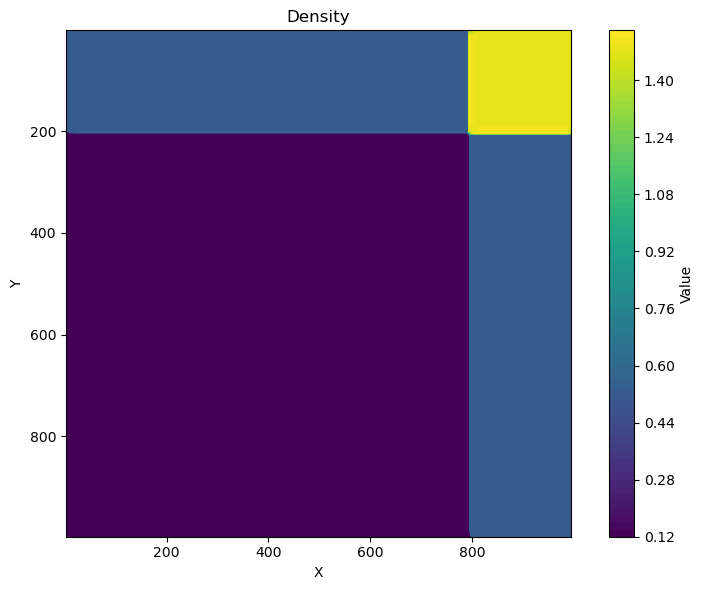

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_contour(data, xc, yc, title, cmap='coolwarm'):
    fig, ax = plt.subplots(figsize=(8, 6))
    cs = ax.contourf(xc, yc, data, levels=80, cmap=cmap)
    fig.colorbar(cs, ax=ax, label='Value')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

def recover_primitives(U0, U1, U2, U3, gamma=1.4):
    """从守恒变量恢复原始变量，与 C++ recoverPrimitives 逻辑一致"""
    rho = U0
    u   = U1 / rho
    v   = U2 / rho
    kinetic  = 0.5 * rho * (u**2 + v**2)
    internal = U3 - kinetic
    p   = (gamma - 1.0) * internal
    return rho, u, v, p

def load_and_combine_data(n_splits, data_dir='result', dx=1.0, dy=1.0, gamma=1.4):
    U0_list, U1_list, U2_list, U3_list = [], [], [], []

    for rank in range(n_splits + 1):
        U0 = np.loadtxt(os.path.join(data_dir, f'U0_{rank}.dat'))
        U1 = np.loadtxt(os.path.join(data_dir, f'U1_{rank}.dat'))
        U2 = np.loadtxt(os.path.join(data_dir, f'U2_{rank}.dat'))
        U3 = np.loadtxt(os.path.join(data_dir, f'U3_{rank}.dat'))

        # 裁掉 ghost cells
        if rank == 0:
            sl = np.s_[:, :-2]
        elif rank == n_splits:
            sl = np.s_[:, 2:]
        else:
            sl = np.s_[:, 2:-2]

        U0_list.append(U0[sl])
        U1_list.append(U1[sl])
        U2_list.append(U2[sl])
        U3_list.append(U3[sl])

    # 水平拼接
    U0_all = np.concatenate(U0_list, axis=1)
    U1_all = np.concatenate(U1_list, axis=1)
    U2_all = np.concatenate(U2_list, axis=1)
    U3_all = np.concatenate(U3_list, axis=1)

    # 恢复原始变量
    rho, u, v, p = recover_primitives(U0_all, U1_all, U2_all, U3_all, gamma)

    # 生成均匀网格坐标
    ny, nx = rho.shape
    x  = np.arange(nx) * dx
    y  = np.arange(ny) * dy
    xc, yc = np.meshgrid(x, y)

    return rho, u, v, p, xc, yc


if __name__ == "__main__":
    n_splits = 0
    data_dir = 'result/100'
    dx    = 1.0
    dy    = 1.0
    gamma = 1.4

    rho, u, v, p, xc, yc = load_and_combine_data(
        n_splits, data_dir=data_dir, dx=dx, dy=dy, gamma=gamma
    )

    vel_mag = np.sqrt(u**2 + v**2)

    # 裁掉最外层一圈边界单元
    sl = np.s_[2:-2, 2:-2]
    plot_contour(vel_mag[sl], xc[sl], yc[sl], 'Velocity Magnitude', cmap='jet')
    plot_contour(p[sl],       xc[sl], yc[sl], 'Pressure',           cmap='jet')
    plot_contour(rho[sl],     xc[sl], yc[sl], 'Density',            cmap='viridis')